# 20. Multi-Agent Patterns (with LangGraph)

**Tier:** Agent Engineering
**Estimated time:** 55 minutes
**Prerequisites:** 19
**Priority:** 🟡 Important — needed once a single agent isn't enough (ties to P4). *If skipped, revisit when:* before building a multi-agent system.
**Source material:** @akasheth_ — Multi-Agent Systems (https://x.com/akasheth_/status/2063593827672461346)

## What You'll Learn
- Three multi-agent patterns: **pipeline** (sequential), **fan-out** (parallel), **specialist team** (routed)
- **LangGraph** — modeling an agent system as an explicit graph of nodes, edges, and shared state
- When the graph abstraction earns its keep over the hand-written loop from notebook 19

## Why This Matters
One agent in a loop (notebook 19) handles a lot, but coordination gets awkward in raw Python once you have several agents, branches, and parallel work. LangGraph makes the *control flow* a first-class object you can see, modify, and reason about — which is exactly what multi-agent systems need.


## From one loop to a graph

Notebook 19's loop was a `while` statement: implicit control flow buried in Python. That's fine for one agent. But once you want "do A and B in parallel, then C," or "route to the right specialist depending on the question," the control flow becomes the hard part — and hiding it inside nested `if`s and loops makes it hard to see or change.

**LangGraph** makes the control flow explicit. You define:
- **State** — a typed dictionary that flows through the system (the shared memory; notebook 22's topic).
- **Nodes** — functions that read the state and return updates to it. Each node is typically one agent or one step.
- **Edges** — which node runs after which. Edges can be unconditional (`A → B`) or **conditional** (a router function picks the next node).

You compile this into a graph and `.invoke()` it. The same three multi-agent patterns map directly onto graph shapes:

1. **Pipeline** — a straight line: `A → B → C`. Each agent refines the previous one's output.
2. **Fan-out** — one node branches to several workers that run in parallel, then a node merges their results.
3. **Specialist team** — a coordinator routes (a conditional edge) to whichever specialist fits the task.

We'll build all three. Note: LangGraph uses `langchain-anthropic`'s `ChatAnthropic` as the model, not the raw SDK — same Claude underneath, different wrapper.


In [1]:
import os, operator
from typing import TypedDict, Annotated
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"   # production default: claude-opus-4-8

from langgraph.graph import StateGraph, START, END

if HAS_ANTHROPIC:
    from langchain_anthropic import ChatAnthropic
    from langchain_core.messages import HumanMessage, SystemMessage
    llm = ChatAnthropic(model=TEACH_MODEL, max_tokens=250,
                        api_key=os.environ["ANTHROPIC_API_KEY"])   # pass key explicitly
    print("ChatAnthropic ready for LangGraph nodes.")
else:
    llm = None
    print("No ANTHROPIC_API_KEY — graphs will be BUILT (offline) but node execution is skipped.")

def call_llm(text, system="You are concise."):
    """Guarded single-message LLM call used inside graph nodes."""
    if llm is None:
        return "[skipped: no ANTHROPIC_API_KEY]"
    try:
        msgs = [SystemMessage(content=system), HumanMessage(content=text)]
        return llm.invoke(msgs).content
    except Exception as e:
        return f"[skipped: {type(e).__name__}: {str(e)[:120]}]"

def describe_graph(compiled):
    g = compiled.get_graph()
    print("nodes:", [n for n in g.nodes if not n.startswith("__")])
    print("edges:", [(e.source, e.target) for e in g.edges])


ChatAnthropic ready for LangGraph nodes.


## Pattern 1 — Pipeline (sequential refinement)

Three agents in a line: a **researcher** lists facts, a **writer** turns them into prose, a **critic** flags one weakness. Each node updates the shared state.


In [2]:
class PipelineState(TypedDict):
    topic: str
    facts: str
    draft: str
    critique: str

def researcher(state):
    return {"facts": call_llm(f"List 3 quick facts about {state['topic']}.", "You are a researcher.")}

def writer(state):
    return {"draft": call_llm(f"Write 2 sentences using these facts: {state['facts']}", "You are a writer.")}

def critic(state):
    return {"critique": call_llm(f"Name ONE weakness of this text in one line: {state['draft']}", "You are a critic.")}

pipeline = StateGraph(PipelineState)
pipeline.add_node("researcher", researcher)
pipeline.add_node("writer", writer)
pipeline.add_node("critic", critic)
pipeline.add_edge(START, "researcher")
pipeline.add_edge("researcher", "writer")
pipeline.add_edge("writer", "critic")
pipeline.add_edge("critic", END)
pipeline_graph = pipeline.compile()

describe_graph(pipeline_graph)
result = pipeline_graph.invoke({"topic": "industrial robot safety"})
print("\nFACTS:", result["facts"][:160])
print("DRAFT:", result["draft"][:160])
print("CRITIQUE:", result["critique"][:160])


nodes: ['researcher', 'writer', 'critic']
edges: [('__start__', 'researcher'), ('researcher', 'writer'), ('writer', 'critic'), ('critic', '__end__')]

FACTS: # Industrial Robot Safety: 3 Quick Facts

1. **Safeguarding Zones Matter**
   Most industrial robots operate within restricted areas protected by physical barri
DRAFT: # Industrial Robot Safety: 2 Sentences

Industrial robots operate within restricted safeguarding zones protected by physical barriers and light curtains to prev
CRITIQUE: The text oversimplifies collaborative robot safety by implying force-limiting technology alone is sufficient, when in practice multiple redundant safety systems


## Pattern 2 — Fan-out (parallel workers, then merge)

One question split into independent sub-questions, each handled by a worker that runs in parallel, then a synthesizer merges them. The key trick is a **reducer**: `Annotated[list, operator.add]` lets several parallel nodes each append to the same `findings` list without clobbering each other.


In [3]:
class FanState(TypedDict):
    question: str
    findings: Annotated[list, operator.add]   # reducer: parallel nodes append, not overwrite
    answer: str

SUBQUESTIONS = {
    "cost": "Answer ONLY the cost angle in one line: {q}",
    "safety": "Answer ONLY the safety angle in one line: {q}",
    "speed": "Answer ONLY the speed angle in one line: {q}",
}

def make_worker(angle, template):
    def worker(state):
        out = call_llm(template.format(q=state["question"]), f"You are a {angle} specialist.")
        return {"findings": [f"[{angle}] {out}"]}
    return worker

def synthesizer(state):
    joined = "\n".join(state["findings"])
    return {"answer": call_llm(f"Combine these angles into one short recommendation:\n{joined}")}

fan = StateGraph(FanState)
for angle, template in SUBQUESTIONS.items():
    fan.add_node(angle, make_worker(angle, template))
    fan.add_edge(START, angle)          # all workers start in parallel
    fan.add_edge(angle, "synthesize")   # all feed the synthesizer
fan.add_node("synthesize", synthesizer)
fan.add_edge("synthesize", END)
fan_graph = fan.compile()

describe_graph(fan_graph)
fan_result = fan_graph.invoke({"question": "Should a small shop buy a robot arm?", "findings": []})
print("\nFINDINGS:")
for f in fan_result["findings"]:
    print("  ", f[:120])
print("\nSYNTHESIS:", fan_result["answer"][:200])


nodes: ['cost', 'safety', 'speed', 'synthesize']
edges: [('__start__', 'cost'), ('__start__', 'safety'), ('__start__', 'speed'), ('cost', 'synthesize'), ('safety', 'synthesize'), ('speed', 'synthesize'), ('synthesize', '__end__')]

FINDINGS:
   [cost] **Cost angle:** Only if annual labor savings exceed the robot's purchase price plus maintenance (~$20-50K upfront
   [safety] From a safety perspective: yes, if it reduces worker exposure to repetitive strain injuries, heavy lifting haza
   [speed] No—the upfront cost, setup time, and maintenance complexity outweigh efficiency gains for typical small shop vol

SYNTHESIS: **Recommendation:** Implement robotics only if you have **high-volume, repetitive tasks** with **documented labor costs exceeding $20-50K annually** and **genuine safety hazards** (repetitive strain, 


## Pattern 3 — Specialist team (routed by a coordinator)

A coordinator inspects the request and a **conditional edge** routes it to the right specialist. This is fan-out's opposite: instead of asking everyone, you ask the *one* agent that fits.


In [4]:
class RouteState(TypedDict):
    request: str
    route: str
    answer: str

def coordinator(state):
    # Cheap keyword router; in production an LLM (or notebook 18's tool-router) makes this call.
    r = state["request"].lower()
    if any(k in r for k in ("price", "cost", "$", "budget")):
        route = "sales"
    elif any(k in r for k in ("error", "broken", "reset", "fix", "wifi")):
        route = "support"
    else:
        route = "general"
    return {"route": route}

def sales(state):    return {"answer": call_llm(f"As a sales rep, answer: {state['request']}")}
def support(state):  return {"answer": call_llm(f"As tech support, answer: {state['request']}")}
def general(state):  return {"answer": call_llm(f"Answer helpfully: {state['request']}")}

team = StateGraph(RouteState)
team.add_node("coordinator", coordinator)
team.add_node("sales", sales); team.add_node("support", support); team.add_node("general", general)
team.add_edge(START, "coordinator")
team.add_conditional_edges("coordinator", lambda s: s["route"],
                           {"sales": "sales", "support": "support", "general": "general"})
for specialist in ("sales", "support", "general"):
    team.add_edge(specialist, END)
team_graph = team.compile()

describe_graph(team_graph)
for request in ["How do I reset the wifi?", "What's the price of the X1?"]:
    out = team_graph.invoke({"request": request})
    print(f"\n'{request}' -> routed to [{out['route']}]")
    print("  ", out["answer"][:140])


nodes: ['coordinator', 'sales', 'support', 'general']
edges: [('__start__', 'coordinator'), ('coordinator', 'general'), ('coordinator', 'sales'), ('coordinator', 'support'), ('general', '__end__'), ('sales', '__end__'), ('support', '__end__')]

'How do I reset the wifi?' -> routed to [support]
   # How to Reset WiFi

**Quick reset (restart router):**
1. Unplug the router power cable
2. Wait 30 seconds
3. Plug it back in
4. Wait 2-3 mi

'What's the price of the X1?' -> routed to [sales]
   I don't have access to current pricing information for the X1. To give you an accurate price, I'd need to know:

1. **Which X1** you're aski


## Raw SDK vs. LangGraph: when does the graph earn its keep?


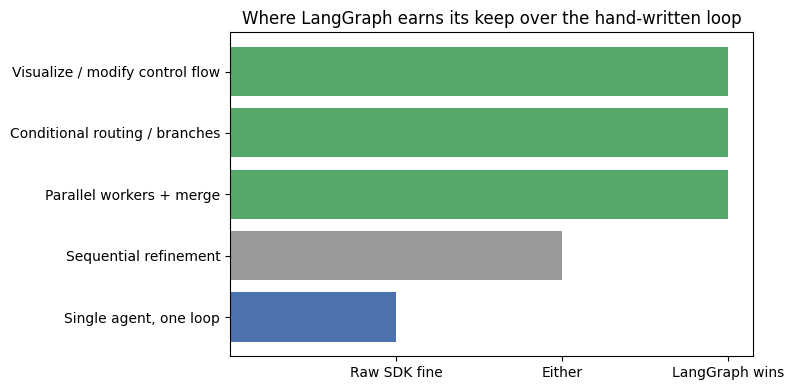

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

comparison = [
    ("Single agent, one loop",        "Raw SDK (nb 19)", 1),
    ("Sequential refinement",          "Either",          2),
    ("Parallel workers + merge",       "LangGraph",       3),
    ("Conditional routing / branches", "LangGraph",       3),
    ("Visualize / modify control flow","LangGraph",       3),
]
labels = [c[0] for c in comparison]
scores = [c[2] for c in comparison]
colors = {1: "#4C72B0", 2: "#999999", 3: "#55A868"}
plt.figure(figsize=(8, 4))
plt.barh(labels, scores, color=[colors[s] for s in scores])
plt.xticks([1, 2, 3], ["Raw SDK fine", "Either", "LangGraph wins"])
plt.title("Where LangGraph earns its keep over the hand-written loop")
plt.tight_layout(); plt.show()


*The raw loop is perfect for a single agent; LangGraph pays off the moment control flow branches, runs in parallel, or needs to be inspected and modified as a structure.*


## Exercises


In [ ]:
# Exercise 1 (Warm-up): Extend the pipeline
# Task: Add a fourth node, "reviser", AFTER the critic that rewrites the draft to address the
#       critique. Wire critic -> reviser -> END and run it.
# Hint: Add a "revised" field to PipelineState; the reviser node reads both state['draft'] and
#       state['critique'].

# YOUR CODE HERE


In [ ]:
# Exercise 2 (Apply): Add a fan-out worker
# Task: Add a fourth angle (e.g. "maintenance") to SUBQUESTIONS and confirm it runs in parallel
#       with the others and shows up in findings — with NO change to the synthesizer.
# Hint: The reducer (Annotated[list, operator.add]) already merges any number of workers; you only
#       add a node + two edges.

# YOUR CODE HERE


In [10]:
# Exercise 3 (Extend): LLM-based routing
# Task: Replace the keyword coordinator with one that asks the LLM to classify the request into
#       'sales', 'support', or 'general' (return ONLY the label). Does routing improve on
#       ambiguous requests the keywords miss?
# Hint: Use call_llm with a tight prompt and strip/lower the result; fall back to 'general' if the
#       label isn't one of the three. This connects back to notebook 18's tool-router idea.

# YOUR CODE HERE
import sys
sys.path.append("../")   # for local dev; remove if installed via pip
from ragkit.llm import generate_tools

def sales(state):    return {"answer": call_llm(f"As a sales rep, answer: {state['request']}")}
def support(state):  return {"answer": call_llm(f"As tech support, answer: {state['request']}")}
def general(state):  return {"answer": call_llm(f"Answer helpfully: {state['request']}")}


SALES_TOOL = {
    "name": "sales",
    "description": "Handle sales-related inquiries.",
    "input_schema": {
        "type": "object",
        "properties": {
            "expression": {"type": "string", "description": "e.g. 'What is the price of the X1?'"},
        },
        "required": ["expression"],
    },
}

SUPPORT_TOOL = {
    "name": "support",
    "description": "Handle technical support inquiries.",
    "input_schema": {
        "type": "object",
        "properties": {
            "expression": {"type": "string", "description": "e.g. 'What's the price of the X1?'"},
        },
        "required": ["expression"],
    },
}


assert HAS_ANTHROPIC, "This exercise requires an Anthropic API key in .env"
def generate_tools_wrapper(question):
    decision = generate_tools(
        question,
        tools=[SALES_TOOL, SUPPORT_TOOL],
        system="Pick the right tool for the question.",
    )
    return decision

for q in ["How do I reset the wifi?", "What's the price of the X1?"]:
    tool = generate_tools_wrapper(q)
    print(f"'{q}' -> routed to [{tool}]")

'How do I reset the wifi?' -> routed to [{'tool_calls': [{'name': 'support', 'input': {'expression': 'How do I reset the wifi?'}}], 'text': '', 'stop_reason': 'tool_use'}]
'What's the price of the X1?' -> routed to [{'tool_calls': [{'name': 'sales', 'input': {'expression': "What's the price of the X1?"}}], 'text': "I'll look up the pricing information for the X1 right away!", 'stop_reason': 'tool_use'}]


<details>
<summary>Show solutions</summary>

```python
# Exercise 1
class PipelineState2(TypedDict):
    topic: str; facts: str; draft: str; critique: str; revised: str
def reviser(state):
    return {"revised": call_llm(
        f"Rewrite to fix this critique.\nText: {state['draft']}\nCritique: {state['critique']}")}
p = StateGraph(PipelineState2)
for name, fn in [("researcher", researcher), ("writer", writer), ("critic", critic), ("reviser", reviser)]:
    p.add_node(name, fn)
p.add_edge(START, "researcher"); p.add_edge("researcher", "writer")
p.add_edge("writer", "critic"); p.add_edge("critic", "reviser"); p.add_edge("reviser", END)
print(p.compile().invoke({"topic": "robot safety"})["revised"][:160])

# Exercise 2
SUBQUESTIONS["maintenance"] = "Answer ONLY the maintenance angle in one line: {q}"
fan2 = StateGraph(FanState)
for angle, template in SUBQUESTIONS.items():
    fan2.add_node(angle, make_worker(angle, template)); fan2.add_edge(START, angle); fan2.add_edge(angle, "synthesize")
fan2.add_node("synthesize", synthesizer); fan2.add_edge("synthesize", END)
print(len(fan2.compile().invoke({"question": "Buy a robot arm?", "findings": []})["findings"]), "findings")

# Exercise 3
def coordinator_llm(state):
    label = call_llm(f"Classify into exactly one of sales/support/general. Return only the word: {state['request']}").strip().lower()
    return {"route": label if label in ("sales", "support", "general") else "general"}
# Swap coordinator -> coordinator_llm in the team graph; LLM routing handles phrasing keywords miss.
```
</details>


## Key Takeaways
- LangGraph turns implicit control flow (notebook 19's `while`) into an explicit graph of **state + nodes + edges**.
- Pipeline = a line of nodes; fan-out = parallel nodes merged by a **reducer** (`Annotated[list, operator.add]`); specialist team = a **conditional edge** routing to one specialist.
- Nodes are just functions that read state and return updates — each node is usually one agent or step.
- LangGraph uses `ChatAnthropic` (langchain-anthropic), the same Claude as the raw SDK behind a different wrapper.
- Use the raw loop for a single agent; reach for LangGraph once control flow branches, parallelizes, or needs to be inspected.

## What's Next
Notebook **21 — Harness Engineering** asks a different question: given the same model and loop, what *surrounding scaffolding* makes an agent reliable? And it adds **LangSmith** so you can finally *see inside* these graph runs instead of guessing.
